# Aquecimento: EDA com dados físicos

Este notebook introduz análise exploratória de dados usando a tabela histórica de Edwin Hubble sobre distância e velocidade radial de galáxias.

Fonte dos dados: NASA/APOD, reprodução do artigo de 1929: https://apod.nasa.gov/diamond_jubilee/1996/hub_1929.html

Pergunta central: **galáxias mais distantes tendem a se afastar mais rápido?**

## 1. Importar bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

## 2. Carregar os dados

Cada linha representa uma galáxia ou sistema próximo listado na Tabela 1 do artigo de Hubble. A distância está em Mpc e a velocidade radial em km/s.

In [77]:
DATA_PATH = Path("dados/hubble_1929_galaxias.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,objeto,distancia_mpc,velocidade_km_s,mt
0,S. Mag.,0.032,170,1.5
1,L. Mag.,0.034,290,0.5
2,NGC 6822,NaN,-130,9.0
3,NGC 598,0.263,-70,7.0
4,NGC 221,0.275,-185,8.8


## 3. Primeira inspeção

Antes de fazer gráficos, precisamos entender o formato da tabela.

In [78]:
df.shape

(24, 4)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   objeto           24 non-null     str    
 1   distancia_mpc    23 non-null     float64
 2   velocidade_km_s  24 non-null     int64  
 3   mt               24 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 900.0 bytes


In [80]:
df.isna().sum()

objeto             0
distancia_mpc      1
velocidade_km_s    0
mt                 0
dtype: int64

In [81]:
df.dropna(inplace=True)

In [82]:
df.isna().sum()

objeto             0
distancia_mpc      0
velocidade_km_s    0
mt                 0
dtype: int64

In [83]:
df.describe()

,distancia_mpc,velocidade_km_s,mt
count,23.000000,23.000000,23.000000
mean,0.941696,395.000000,8.430435
std,0.642290,363.440004,2.746971
min,0.032000,-220.000000,0.500000
25%,0.475000,185.000000,8.350000
50%,0.900000,300.000000,9.100000
75%,1.250000,575.000000,9.800000
max,2.000000,1090.000000,12.000000


## 4. Dicionário das colunas

- `objeto`: identificação do objeto astronômico
- `distancia_mpc`: distância estimada, em megaparsecs (Mpc)
- `velocidade_km_s`: velocidade radial medida, em km/s
- `mt`: magnitude aparente visual usada por Hubble

Velocidade positiva indica afastamento. Velocidade negativa indica aproximação.

## 5. Distribuições

Uma distribuição mostra como os valores de uma variável se espalham.

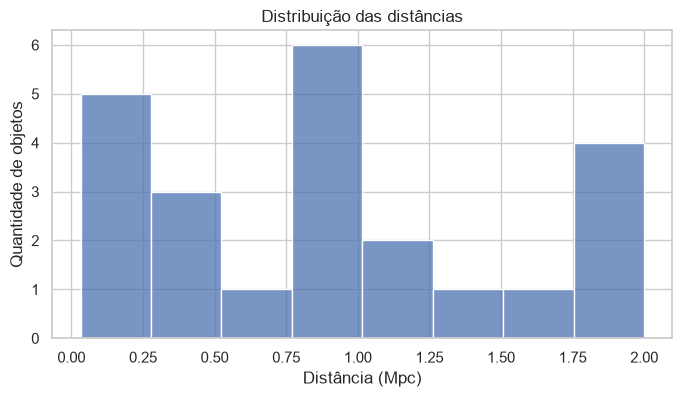

In [84]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="distancia_mpc", bins=8, ax=ax)
ax.set_title("Distribuição das distâncias")
ax.set_xlabel("Distância (Mpc)")
ax.set_ylabel("Quantidade de objetos")
plt.show()

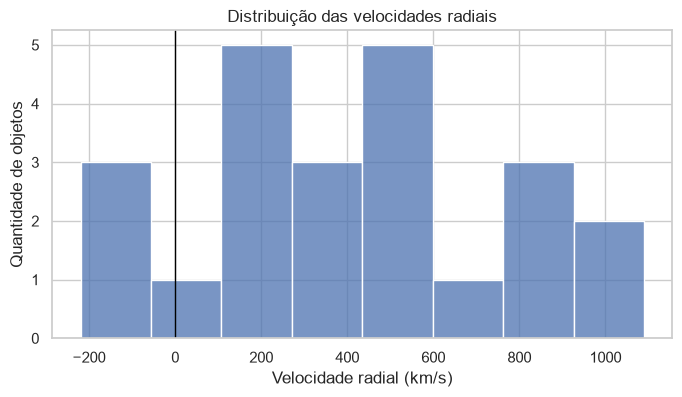

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="velocidade_km_s", bins=8, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Distribuição das velocidades radiais")
ax.set_xlabel("Velocidade radial (km/s)")
ax.set_ylabel("Quantidade de objetos")
plt.show()

In [86]:
df[df["velocidade_km_s"] < 0]

,objeto,distancia_mpc,velocidade_km_s,mt
3,NGC 598,0.263,-70,7.0
4,NGC 221,0.275,-185,8.8
5,NGC 224,0.275,-220,5.0
11,NGC 3031,0.900,-30,8.3


As velocidades negativas aparecem em objetos próximos. Isso é uma boa oportunidade para discutir movimentos locais: a expansão geral não impede movimentos particulares em regiões próximas.

## 6. Relação entre distância e velocidade

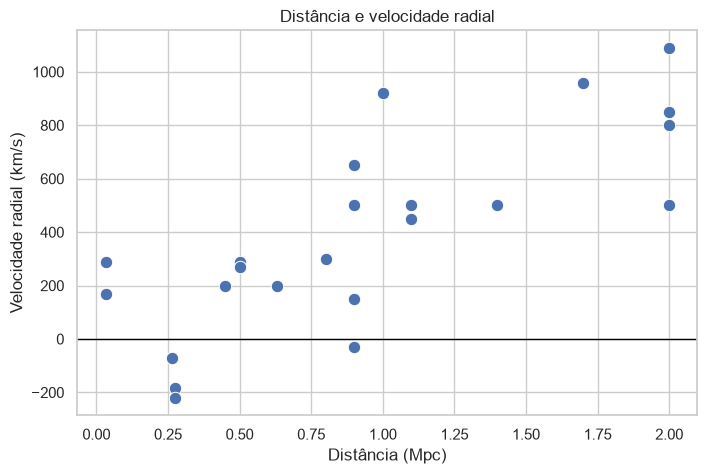

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="distancia_mpc", y="velocidade_km_s", s=80, ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Distância e velocidade radial")
ax.set_xlabel("Distância (Mpc)")
ax.set_ylabel("Velocidade radial (km/s)")
plt.show()

Visualmente, parece haver uma tendência: objetos mais distantes tendem a ter velocidades maiores. Agora vamos colocar uma reta apenas como resumo exploratório.

In [88]:
coef_angular, intercepto = np.polyfit(df["distancia_mpc"], df["velocidade_km_s"], deg=1)

coef_angular, intercepto

(np.float64(439.2124493187092), np.float64(-18.60445390408334))

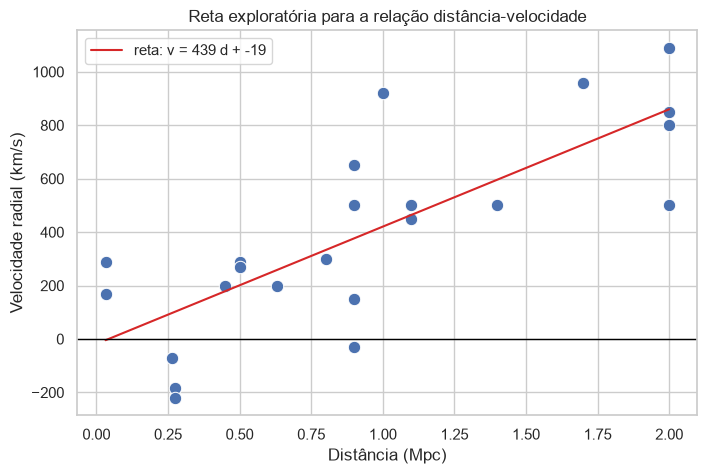

In [89]:
x = np.linspace(df["distancia_mpc"].min(), df["distancia_mpc"].max(), 100)
y = coef_angular * x + intercepto

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="distancia_mpc", y="velocidade_km_s", s=80, ax=ax)
ax.plot(x, y, color="tab:red", label=f"reta: v = {coef_angular:.0f} d + {intercepto:.0f}")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Reta exploratória para a relação distância-velocidade")
ax.set_xlabel("Distância (Mpc)")
ax.set_ylabel("Velocidade radial (km/s)")
ax.legend()
plt.show()

A inclinação da reta tem unidade de km/s/Mpc. Essa é a mesma unidade usada para a constante de Hubble.

Importante: esta estimativa usa dados históricos de 1929. O objetivo aqui é aprender EDA, não medir o valor moderno da constante de Hubble.

## 7. Agrupamento simples

Vamos separar objetos próximos e distantes para comparar médias.

In [90]:
df = df.copy()
df["faixa_distancia"] = pd.cut(
    df["distancia_mpc"],
    bins=[0, 0.5, 1.0, 1.5, 2.1],
    labels=["ate 0.5", "0.5 a 1.0", "1.0 a 1.5", "1.5 a 2.0"],
)

df.groupby("faixa_distancia", observed=True).agg(
    objetos=("objeto", "count"),
    distancia_media=("distancia_mpc", "mean"),
    velocidade_media=("velocidade_km_s", "mean"),
).round(2)

,objetos,distancia_media,velocidade_media
faixa_distancia,,,
ate 0.5,8,0.29,93.12
0.5 a 1.0,7,0.86,384.29
1.0 a 1.5,3,1.20,483.33
1.5 a 2.0,5,1.94,840.00


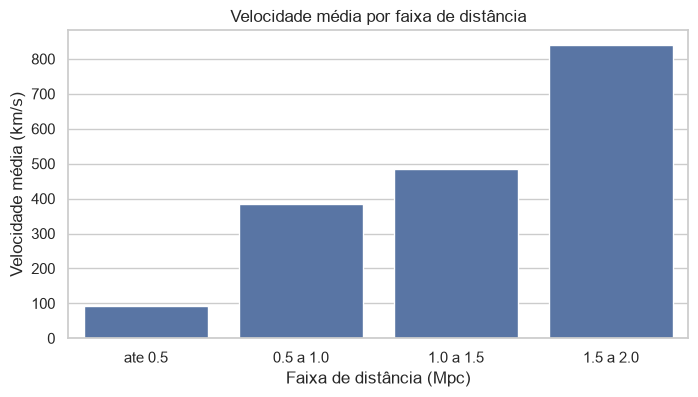

In [91]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x="faixa_distancia", y="velocidade_km_s", errorbar=None, ax=ax)
ax.set_title("Velocidade média por faixa de distância")
ax.set_xlabel("Faixa de distância (Mpc)")
ax.set_ylabel("Velocidade média (km/s)")
plt.show()

## 8. Conclusão provisória

Responda em poucas linhas:

1. O que os dados sugerem?
2. O que os dados não provam sozinhos?
3. Que medições melhores ajudariam?

Exemplo:

> Nesta amostra histórica, galáxias mais distantes tendem a ter velocidades radiais maiores. A relação parece aproximadamente linear, mas há grande dispersão e objetos próximos com velocidade negativa. Isso sugere uma relação física importante, mas a amostra pequena e as incertezas das distâncias limitam a conclusão.

## 9. Ponte para o projeto de exoplanetas

No projeto principal, o raciocínio será o mesmo:

- entender o que cada linha representa;
- entender o significado físico de cada coluna;
- verificar unidades;
- procurar valores ausentes e extremos;
- comparar grupos;
- fazer gráficos interpretáveis;
- tomar cuidado com vieses antes de concluir.